
# Regresión Lineal Múltiple en Minería de Datos

La **regresión lineal múltiple** permite predecir el valor de una variable dependiente en función de varias variables independientes.

En este ejemplo, aplicaremos la técnica a la **base de datos California Housing**, cuyo objetivo es predecir el **valor medio de las viviendas en distritos de California** en función de variables socioeconómicas y geográficas.



## Variables del dataset

- MedInc: Ingreso medio por hogar en el distrito.
- HouseAge: Edad media de las casas en el distrito.
- AveRooms: Número promedio de habitaciones por hogar.
- AveBedrms: Número promedio de dormitorios por hogar.
- Population: Población del distrito.
- AveOccup: Número promedio de personas por hogar.
- Latitude: Latitud geográfica.
- Longitude: Longitud geográfica.

**Variable objetivo:**
- MedHouseVal: Valor medio de las casas (en cientos de miles de dólares).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Cargar dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# Vista inicial
print("Dimensiones:", df.shape)
df.head()


Dimensiones: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


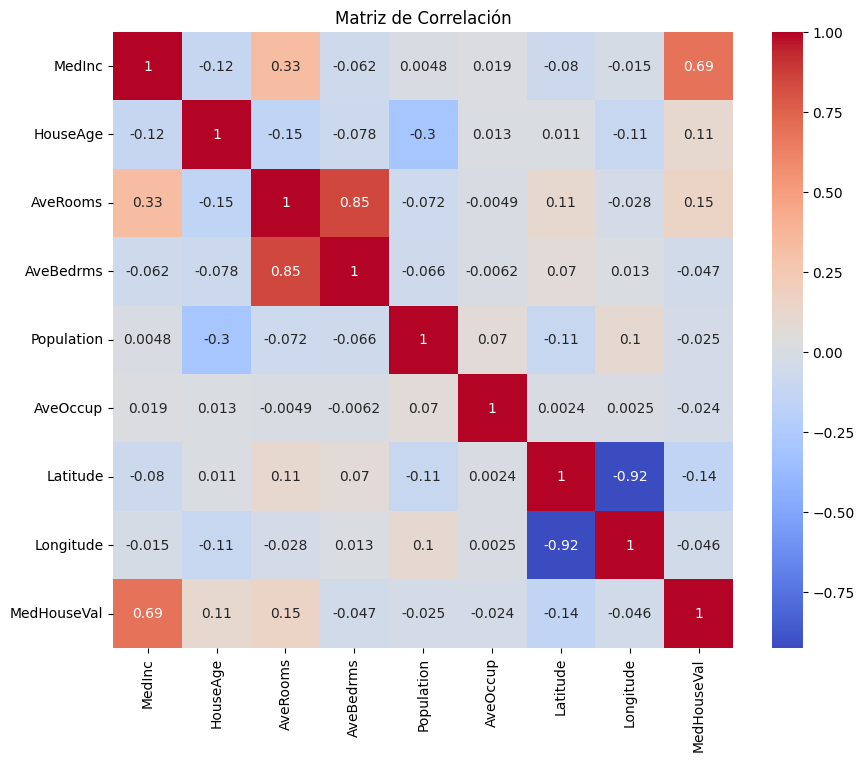

In [ ]:
# Estadísticas descriptivas
df.describe()

# Correlación entre variables
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlación")
plt.show()


In [ ]:
X = df.drop("MedHouseVal", axis=1)  # Variables predictoras
y = df["MedHouseVal"]               # Variable objetivo

# División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Resultados
print("Intercepto:", modelo.intercept_)
coef = pd.DataFrame(modelo.coef_, X.columns, columns=["Coeficiente"])
coef.sort_values(by="Coeficiente", ascending=False)


Intercepto: -37.02327770606409


,Coeficiente
AveBedrms,0.783145
MedInc,0.448675
HouseAge,0.009724
Population,-0.000002
AveOccup,-0.003526
AveRooms,-0.123323
Latitude,-0.419792
Longitude,-0.433708


## Ecuación del Modelo de Regresión Lineal Múltiple

**Forma general**
$$
\hat{y} = \beta_0 + \sum_{j=1}^{p} \beta_j x_j
$$

**Aplicado a California Housing**
$$
\widehat{\text{MedHouseVal}} =
\beta_0
+ \beta_1\,\text{MedInc}
+ \beta_2\,\text{HouseAge}
+ \beta_3\,\text{AveRooms}
+ \beta_4\,\text{AveBedrms}
+ \beta_5\,\text{Population}
+ \beta_6\,\text{AveOccup}
+ \beta_7\,\text{Latitude}
+ \beta_8\,\text{Longitude}
$$

**Donde:**
- $\hat{y}$ = Valor medio estimado de las viviendas.
- $\beta_0$ = Intercepto.
- $\beta_j$ = Coeficiente de la variable $x_j$, que indica su efecto marginal manteniendo las demás constantes.



In [ ]:
y_pred = modelo.predict(X_test)

print("Error cuadrático medio (MSE):", mean_squared_error(y_test, y_pred))
print("Coeficiente de determinación (R^2):", r2_score(y_test, y_pred))


Error cuadrático medio (MSE): 0.5558915986952444
Coeficiente de determinación (R^2): 0.5757877060324508


## Conclusiones

- El modelo permite estimar cómo influyen variables socioeconómicas y geográficas en el valor de las viviendas.
- **MedInc (ingreso medio)** suele ser la variable más influyente de manera positiva.
- Algunas variables como **AveBedrms o Latitude** tienen efectos negativos sobre el valor.
- El **R²** nos indica qué porcentaje de la variabilidad de los precios se explica con este modelo.


#  Cómo mejorar el modelo de regresión lineal múltiple

Aunque la regresión lineal múltiple es una herramienta poderosa para analizar la relación entre varias variables y una respuesta, su desempeño puede ser limitado cuando:

- Las variables están en **escalas diferentes**.  
- Existen **muchas variables poco relevantes** que introducen ruido.  
- Hay **interacciones entre variables** que el modelo lineal no captura.  
- La relación entre predictores y la variable objetivo **no es lineal**.  

A continuación, exploraremos algunas formas de mejorar el modelo.


## 1. Normalización o estandarización de variables

Las variables tienen escalas muy diferentes (ejemplo: *ingreso medio* vs. *latitud*).  
Esto puede hacer que algunas dominen sobre otras aunque no sean tan influyentes.

**Solución:** escalar los datos, restando la media y dividiendo por la desviación estándar de cada variable.

De esta manera, todas las variables quedan en una escala comparable (media 0 y desviación estándar 1).


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo2 = LinearRegression()
modelo2.fit(X_train_scaled, y_train)

y_pred2 = modelo2.predict(X_test_scaled)
print("MSE:", mean_squared_error(y_test, y_pred2))
print("R²:", r2_score(y_test, y_pred2))


MSE: 0.5558915986952442
R²: 0.575787706032451


## 2. Selección de variables

No todas las variables aportan información útil. Algunas pueden introducir **ruido** y afectar negativamente el modelo.  

**Solución:** aplicar métodos de selección de variables, como **RFE (Recursive Feature Elimination)**, para quedarnos con las más relevantes.  

Esto ayuda a simplificar el modelo, mejorar su desempeño y hacerlo más interpretable.


In [ ]:
from sklearn.feature_selection import RFE

selector = RFE(modelo, n_features_to_select=5)  # seleccionar las 5 más importantes
selector.fit(X_train, y_train)

print("Variables seleccionadas:", X.columns[selector.support_])


Variables seleccionadas: Index(['MedInc', 'AveRooms', 'AveBedrms', 'Latitude', 'Longitude'], dtype='object')


## 3. Inclusión de interacciones

A veces, el efecto de una variable depende del valor de otra.  
Por ejemplo, el impacto del **ingreso medio (MedInc)** en el precio de la vivienda puede variar según el **número de habitaciones promedio (AveRooms)**.

**Solución:** crear variables de interacción o usar transformaciones polinómicas.  
Esto permite al modelo capturar relaciones más complejas entre las variables.


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

modelo3 = LinearRegression()
modelo3.fit(X_train_poly, y_train)

y_pred3 = modelo3.predict(X_test_poly)
print("MSE:", mean_squared_error(y_test, y_pred3))
print("R²:", r2_score(y_test, y_pred3))


MSE: 0.4946973441164448
R²: 0.6224862983001465


## 4. Probar modelos no lineales

La regresión lineal supone que la relación entre las variables y el resultado es **lineal**.  
En muchos problemas reales, esto no se cumple del todo.

 **Solución:** probar modelos más flexibles, como:  
- **Regresión Ridge o Lasso** (regresiones lineales con regularización).  
- **Árboles de decisión** y **Random Forest**.  
- **Modelos de boosting** (ejemplo: XGBoost, Gradient Boosting).  

Estos métodos suelen mejorar la precisión predictiva, aunque sacrifican algo de interpretabilidad.


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("MSE (RF):", mean_squared_error(y_test, y_pred_rf))
print("R² (RF):", r2_score(y_test, y_pred_rf))


MSE (RF): 0.2553684927247781
R² (RF): 0.8051230593157366


##  Resumen

- **Regresión lineal múltiple:** buena para interpretar relaciones entre variables.  
- **Normalización:** hace comparables todas las variables.  
- **Selección de variables:** reduce ruido y mejora el modelo.  
- **Interacciones:** permiten capturar relaciones más realistas.  
- **Modelos no lineales:** aumentan la precisión predictiva.  

En la práctica, debemos decidir entre **interpretabilidad** (modelos lineales) y **precisión** (modelos más complejos).
